<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>

## Trabajo Semanal Número: 0

</center>

<center>

### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

El objetivo de la TS0 consiste en familiarizarse en la construcción de señales, en especial aquellas con ruido. Para este caso, se decidió por una señal senoidal, cuya fórmula general se detalla a continuación:

<h3 style="text-align: center;">x(t) = A. sin (2π*f*t + ϕ ) + DC</h3>

Donde A es la amplitud, f la frecuencia medida en Herz, t el tiempo,  ϕ es al fase inicial y DC el valor del offset.  

<h3 style="text-align;">GENERO UNA SEÑAL SENOIDAL</h3>

In [6]:
#Creo el bloque para hacer la función 
import numpy as np
def mi_funcion_sen(vmax, dc, ff, ph, nn,fs): #Vmax es la amplitud, dc el valor de continua, ff la frecuencia,
    # ph la faso, nn numero de muestras, y fs recuencia de muestreo.  
    # El tiempo de muestreo.
    ts=1/fs
    #Creo el vector de tiempo. 
    # Generamos un vector de numeros que tengan la misma cantidad que de muestras, ahora lo tengo que multiplicar por ts, para obtener tt
    x = np.arange(nn).reshape(-1,1) #Este comando me lo explicó David en una consulta que le hice, y el reshape lo busqué
    #En Chat GPT, sirve para asegurarme que tengo una sola columna, es (filas, columnas) el -1 hace que se rellene automáticamentela cant filas. 
    tt=x*ts 
    #Ahora sí, hago la señal senoidal. 
    xx = vmax*np.sin(2*np.pi*ff*tt+ph) + dc
    return tt,xx

<h3 style="text-align;">IMPLEMENTO LA SEÑAL SENOIDAL</h3>

El tamaño del vector tiempo es: (100, 1)
El tamaño del vector de la función es: (100, 1)


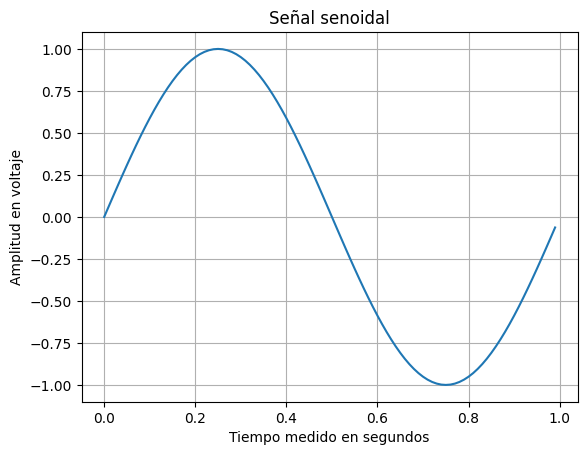

In [9]:
#Llamo a la funcion y hago el grafico
import matplotlib.pyplot as plt #matplotlib es la librería para graficar, pyplot es el modulo que tiene las erramientas graficas. 
#Y después el plt es un nombre que ponemos para no tener que escribir el entero. 
N=100
fs=100
#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs)
# Me aseguro de que xx y tt son vectores Nx1.
print("El tamaño del vector tiempo es:", tt.shape) #Me imprime el tamaño de tt. 
print("El tamaño del vector de la función es:",xx.shape) #Me imprime el tamaño de tt. 
plt.plot(tt, xx) #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundos")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.

<h3 style="text-align;">EXPERIMENTOS PARA DISTINTAS FRECUENCIAS</h3>

Se comienza a experimentar con la señal construida, variando su frecuencia, a la vez que se fija su frecuencia de muestreo (fs=100Hz), con el objetivo de analizar el fenóemno de aliasing y el rol de la frecuencia de Nyquist. 
    El aliasing es un suceso que ocurre cuando una señal es muestreada a una frecuencia que resulta insuficiente, es decir, cuando no se cumple el criterio de Nyquist que fija la frecuencia máxima a la que es posible muestrear una señal. Se rige por la siguiente fórmula: f < fs/2 
    En este caso sería la frecuencia de Nyquist sería de 50 Hz, ya que 100Hz/2.  
    

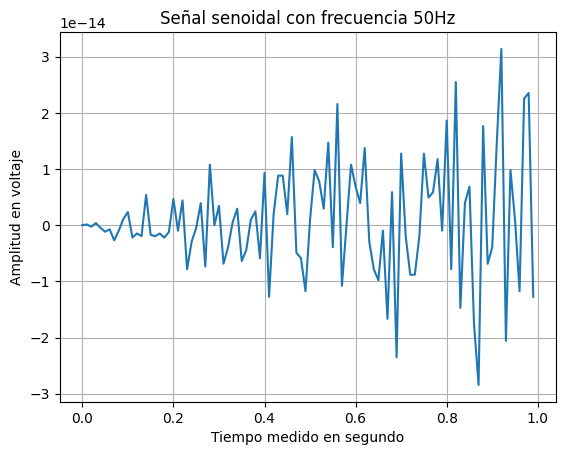

In [14]:
#PRIMER FRECUENCIA: 50HZ

#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=1, dc=0, ff=50, ph=0, nn=N, fs=fs)
# Me aseguro de que xx y tt son vectores Nx1.
plt.plot(tt, xx) #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal con frecuencia 50Hz")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.



En este caso, nos encontramo al límite de la fecuencia de Nyquist, la señal se observa distorsinada, claramente no es la senoidal esperada. Esto puede ocurrir debido a que tenemos pocos puntos por período.
        Los puntos por período se definen de la siguiente manera: 
<h3 style="text-align: center;">Puntos por período: fs/f</h3>
A medida que aumenta la frecuencia, estos puntos van disminuyendo, hasya que en el umbral tenemos solo 2 puntos por período, siendo insuficientes para describir el comportamiento de la senoidal.

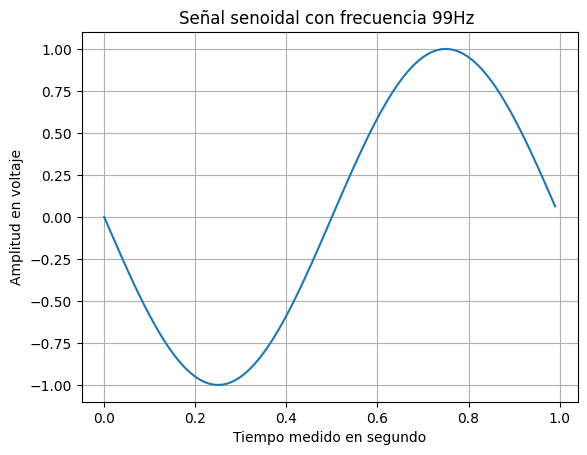

In [15]:
# SEGUNDA FRECUENCIA 99HZ

#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=1, dc=0, ff=99, ph=0, nn=N, fs=fs)
# Me aseguro de que xx y tt son vectores Nx1.
plt.plot(tt, xx) #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal con frecuencia 99Hz ")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.

En este caso, donde la frecuencia de la señal es cercana a la frecuencia de muestreo, mientras que supera por casi el doble a la de Nyquist, se puede observar una senoidal de baja frecuencia, similar a la obtenida inicialmente, cuando la frecuencia era 1Hz. 
Sin embargo, esta se halla invertida con respecto a la original. 
La frecuencia de aliasing se encuentra dada por la siguiente expresión:
$$
f_{alias} = |f_s - f| = |100 - 99| = 1 \, \text{Hz}
$$
Esto explica el porqué observamos una señal que parece ser de baja frecuencia, a pesar de que estamos frente a una de alta. 
El sistema de muestreo no puede seguirle el ritmo a la señal, por lo que las muestras se toman en puntos que corresponden a la fase opuesta de la señal, dando como resultado ese corrimiento de fase que se observa en el gráfico.

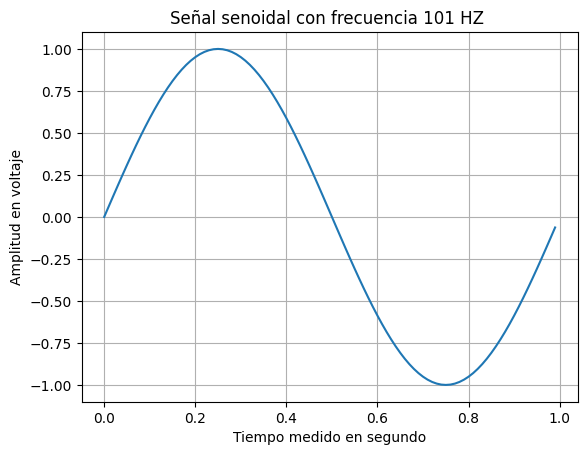

In [16]:
# TERCERA FRECUENCIA 101 HZ 

#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=1, dc=0, ff=101, ph=0, nn=N, fs=fs)
# Me aseguro de que xx y tt son vectores Nx1.
plt.plot(tt, xx) #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal con frecuencia 101 HZ ")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.

En este caso ocurre algo similar al anterior, debido a que:
$$
f_{alias} = |f_s - f| = |100 - 101| = 1 \, \text{Hz}
$$
Sin embargo, en este caso no se observa un corrimiento de fase.

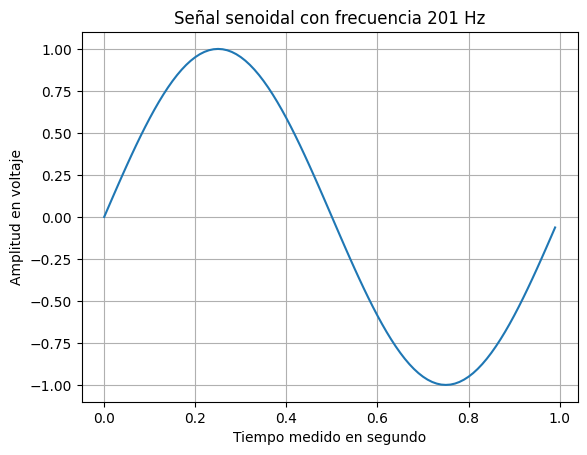

In [17]:
# CUARTA FRECUENCIA  201 HZ 

#Llamo a la función, la escribo como tt,xx
tt,xx = mi_funcion_sen(vmax=1, dc=0, ff=201, ph=0, nn=N, fs=fs)
# Me aseguro de que xx y tt son vectores Nx1.
plt.plot(tt, xx) #Acá dibuja la función que creamos. 
plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal senoidal con frecuencia 201 Hz")
plt.grid(True) # Ponemos una grilla
plt.show() #Esto muestra en pantalla el gráfico.

La frecuencia de Aliasing no ocurre exclusivamente en la frecuencia de muestreo, sino que también se efectúa en sus múltiplos. 
$$
f_{alias} = \left| k \cdot f_s - f \right| \quad 
$$
Donde k, corresponde a un número entero que representa dichos múltiplos de la frecuencia de muestreo. 
$$
f_{alias} = |f_s - f| = |100 - 101| = 1 \, \text{Hz}
$$

<h3 style="text-align;">GRÁFICO COMPARATIVO DE LAS CUATRO FRECUENCIAS</h3>

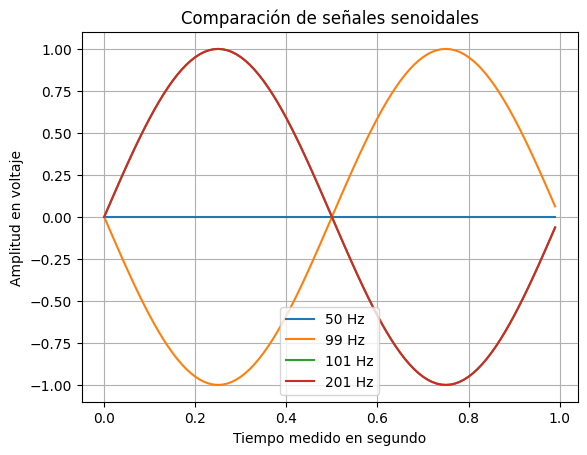

In [19]:
# Genero de nuevo todas las señales, porque no me di cuenta de guardarla antes con otros nombres. 
tt, x1 = mi_funcion_sen(vmax=1, dc=0, ff=50, ph=0, nn=N, fs=fs)
_,  x2 = mi_funcion_sen(vmax=1, dc=0, ff=99, ph=0, nn=N, fs=fs)
_,  x3 = mi_funcion_sen(vmax=1, dc=0, ff=101, ph=0, nn=N, fs=fs)
_,  x4 = mi_funcion_sen(vmax=1, dc=0, ff=201, ph=0, nn=N, fs=fs)

# Grafico todas las señales juntas
plt.plot(tt, x1, label="50 Hz")
plt.plot(tt, x2, label="99 Hz")
plt.plot(tt, x3, label="101 Hz")
plt.plot(tt, x4, label="201 Hz")

plt.xlabel("Tiempo medido en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Comparación de señales senoidales")
plt.legend()  #Lo busqué en el Chat, cómo poner para identificar cuál es cuál.
plt.grid(True)
plt.show()

Cabe destacar la importancia de la frecuencia de Nyquist a la hora de muestrear correctamente una señal.
Cuando la frecuencia de la señal se halla por debajo de la frecuencia de Nyquist, la señal se representra correctamente debido a que hay suficientes puntos por período, sin embargo, al ir aumentando la frecuencia de la onda, estos puntos van disminuyendo, provocando fenómenos como el de aliasing, donde se dan falsas frecuencias haciendo indistinguible las frecuencias reales de la señal.  

En conclusión, esta práctica nos demuestra que la calidad en el proceso de muestreo, no depende solo de los datos persé, sino también de hacerlo a una frecuencia adecuada, ya que si no se respesta el criterio de Nyquist, la información original de la señal puede perderse, a la vez que aparecen distorsiones irreversibles, que a su vez deben saber interpretarse correctamente.

<h3 style="text-align;">GENERACIÓN DE UNA SEÑAL TRIANGULAR</h3>

Ahora buscamos generar otra señal, además de la sinusoidal que ya vimos, podría ser una cuadrada o triangular.

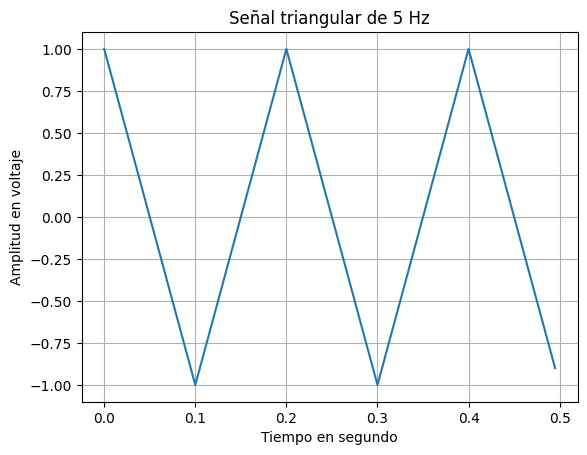

In [26]:
# AHORA GENERO OTRA SEÑAL, EN ESPECÍFICO UNA SEÑAL TRAINGULAR, TAMBIÉN PODRÍA SER CUADRADA.
N = 100
fs = 200
vmax = 1
ff = 5
dc = 0
ts = 1/fs
tt = np.arange(N).reshape(-1,1) * ts  # Me aseguro que sea un vector Nx1, 
xx = 2*vmax*np.abs(2*((ff*tt) % 1) - 1) - vmax + dc  # señal triangular, sinceramente tuve que buscarla, porque no se me ocurría cómo hacerla, sabía
#que tenía que ser una lineal creciente y otra decreciente que se repitiera cíclicamente. 
#((ff*tt) repite tantas veces como diga la frecuencia en un segundo. 
# 2 * vmax * (...) - vmax , ajusta la amplitudentre -vmax y +vmax.
# El valor absoluto convierte la rampa en  forma de V y el %1 hace que se reinicie en cada período, pero esto no lo entendí bien, me anoté para preguntarlo. 
plt.plot(tt, xx)
plt.xlabel("Tiempo en segundo")
plt.ylabel("Amplitud en voltaje")
plt.title("Señal triangular de 5 Hz")
plt.grid(True)
plt.show()

La señal triangular se construyó a partir de una rampa periódica,  usando el operador módulo para garantizar dicha repetición en cada uno de los períodos, y el valor absoluto para generar la forma triangular. 